In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from features import find_correspondence_points
from sfm import linear_triangulation, ensure_homogeneous, compute_essential_matrix_from, essential_factorization
from ransac_methods import ransac_essential_matrix

In [2]:
img1_path = 'left20'
img2_path = 'right20'

img1 = cv2.imread('imgs/'+img1_path+'.JPG')
img2 = cv2.imread('imgs/'+img2_path+'.JPG')

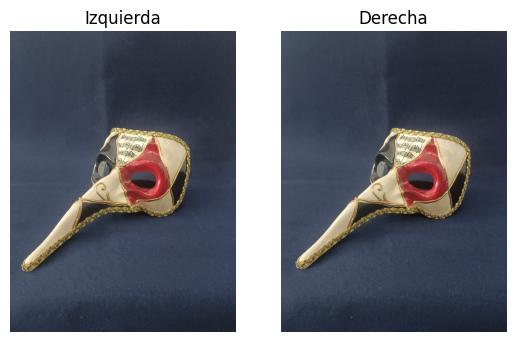

In [3]:
# Convertir a RGB
left = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
right = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2)

axs[0].imshow(left)
axs[0].axis('off')
axs[0].set_title('Izquierda')

axs[1].imshow(right)
axs[1].axis('off')
axs[1].set_title('Derecha')

plt.show()

In [4]:
import os

if os.path.exists("keypoints/pts1-"+img1_path+".npy") and os.path.exists("keypoints/pts2-"+img2_path+".npy"):
    # Cargo los puntos homologos calculados con SIFT que han sido calculados anteriormente
    pts1 = np.load("keypoints/pts1-"+img1_path+".npy")
    pts2 = np.load("keypoints/pts2-"+img2_path+".npy")
else:
    # Usamos el algoritmo SIFT para obtener los puntos homólogos
    pts1, pts2 = find_correspondence_points(img1, img2)
    
    #Guardar los puntos
    np.save("keypoints/pts1-"+img1_path+".npy", pts1)
    np.save("keypoints/pts2-"+img2_path+".npy", pts2)

In [5]:
pts1.shape[1]

3792

In [6]:
K = np.load("K_matrix.npy")
K

array([[3.50914208e+03, 0.00000000e+00, 1.70748595e+03],
       [0.00000000e+00, 3.52578723e+03, 2.31419085e+03],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

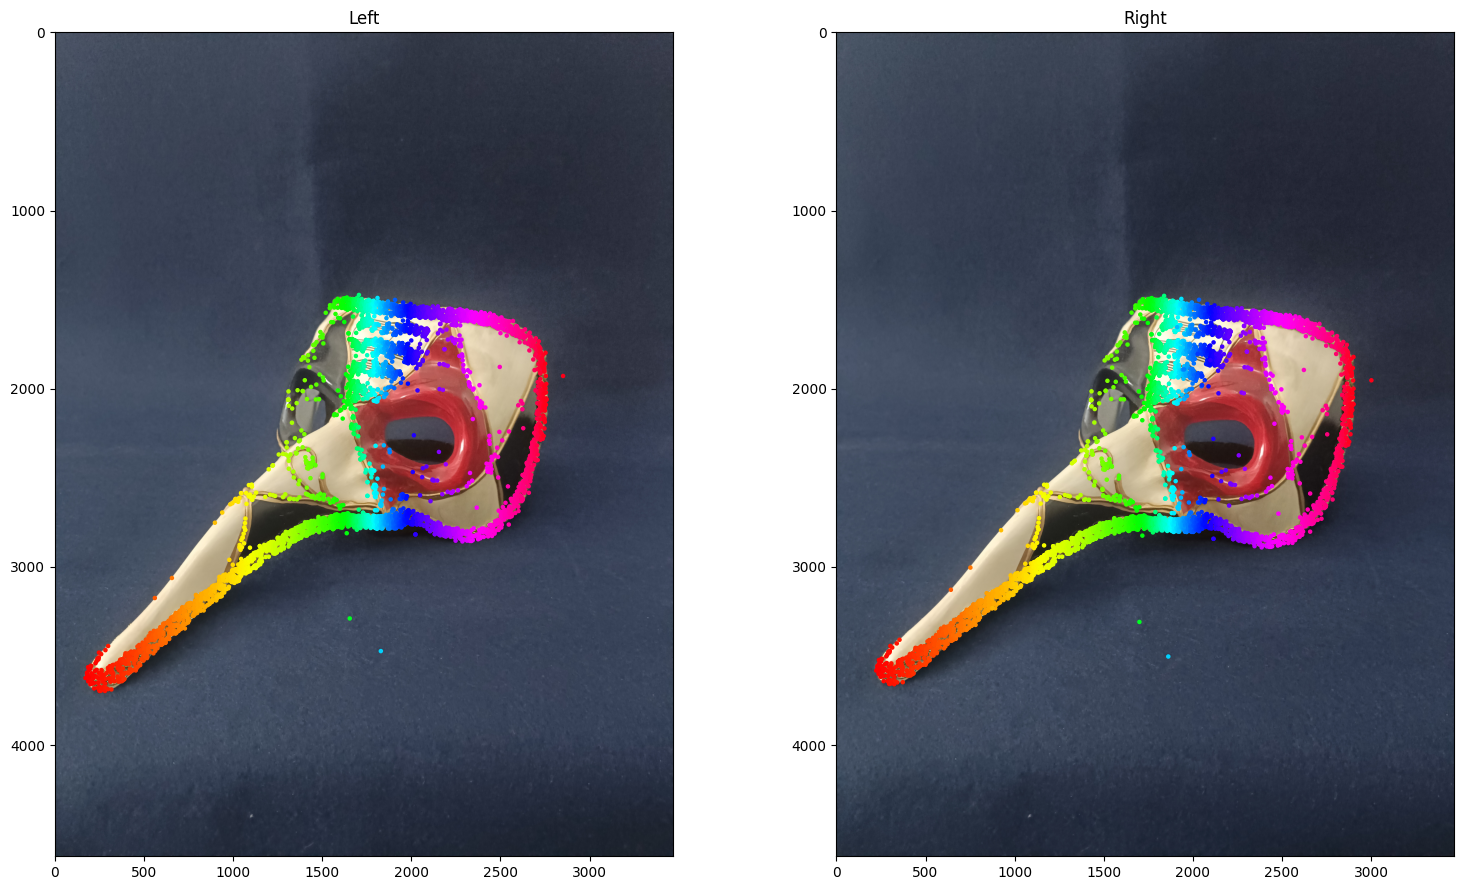

In [7]:
# Rango de puntos
start = 0
end = pts1.shape[1]

pts1_sub = pts1[:, start:end]
pts2_sub = pts2[:, start:end]

N = pts1_sub.shape[1]
#colors = np.random.rand(N,3) # Colores Aleatorios
colors = plt.cm.hsv(np.linspace(0, 1, N)) # Coores más vivos

plt.figure(figsize=(16,9))

plt.subplot(1,2,1)
plt.imshow(left)
plt.scatter(pts1_sub[0], pts1_sub[1], s=5, c=colors)
plt.title("Left")
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(right)
plt.scatter(pts2_sub[0], pts2_sub[1], s=5, c=colors)
plt.title("Right")
plt.axis('on')

plt.tight_layout()
plt.savefig('plots/keypoints_'+img1_path+'_and_'+img2_path+'.png')
plt.show()

In [8]:
#ran_idx = np.random.randint(start, end, size=100)

In [9]:
E, idx = ransac_essential_matrix(pts1, pts2, K , K)
print(len(idx))
E

3792


array([[  0.35284126, -13.34752061,  -2.96687732],
       [ 13.39527494,   0.27662995,  -2.04688848],
       [  2.94822692,   2.43198831,   0.06667794]])

In [10]:
R, t, z = essential_factorization(pts1, pts2, K, K, E, verbose=True)

Orientación correcta encontrada


In [11]:
print(R)
print(t)
print(z)

[[ 0.9994874   0.02106206  0.02411092]
 [-0.02101068  0.99977641 -0.00238205]
 [-0.0241557   0.00187424  0.99970645]]
[-0.17068299  0.21608176 -0.96134072]
[3.9573871  4.54211741]


In [17]:
R @ R.T

array([[ 1.00000000e+00,  6.07838263e-16, -1.68914005e-16],
       [ 6.07838263e-16,  1.00000000e+00, -2.19202527e-17],
       [-1.68914005e-16, -2.19202527e-17,  1.00000000e+00]])

In [ ]:
P2 = np.vstack([R,t])
P2 = P2.T
P2

In [38]:
np.save("P2_matrix.npy", P2)